In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Optional
from dataclasses import dataclass
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Lấy đầu ra của CV và Module 1 chỗ này làm đầu vào 

--  trong trường hợp đầu ra CV không khớp mày nhắn t liền nhaa

In [2]:
@dataclass
class CVFeatures:
    blink_rate: int
    posture_score: float
    screen_distance: float
    duration_minutes: int
    head_angle: float
    eye_closure_duration: float
    risk_level: float


@dataclass
class NLPFeatures:
    discomfort_level: int
    severity_label: str
    confidence: float
    probabilities: Dict[str, float]
    extracted_symptoms: List[str]
    original_text: str

## Này ví dụ thôi nha


In [3]:
cv_data_samples = [
    {
        "user_id": "user_001",
        "session_id": "session_20260215_143022",
        "timestamp": "2026-02-15T14:30:22",
        "blink_rate": 8,
        "posture_score": 45.2,
        "screen_distance": 35.5,
        "duration_minutes": 125,
        "head_angle": 28.3,
        "eye_closure_duration": 85.2,
        "risk_level": 0.72
    },
    {
        "user_id": "user_002",
        "session_id": "session_20260215_095530",
        "timestamp": "2026-02-15T09:55:30",
        "blink_rate": 12,
        "posture_score": 68.5,
        "screen_distance": 55.0,
        "duration_minutes": 45,
        "head_angle": 12.5,
        "eye_closure_duration": 110.8,
        "risk_level": 0.35
    },
    {
        "user_id": "user_003",
        "session_id": "session_20260215_110015",
        "timestamp": "2026-02-15T11:00:15",
        "blink_rate": 18,
        "posture_score": 85.0,
        "screen_distance": 62.0,
        "duration_minutes": 25,
        "head_angle": 8.2,
        "eye_closure_duration": 125.5,
        "risk_level": 0.15
    },
    {
        "user_id": "user_004",
        "session_id": "session_20260215_163045",
        "timestamp": "2026-02-15T16:30:45",
        "blink_rate": 6,
        "posture_score": 32.8,
        "screen_distance": 28.0,
        "duration_minutes": 180,
        "head_angle": 35.7,
        "eye_closure_duration": 72.3,
        "risk_level": 0.88
    },
    {
        "user_id": "user_005",
        "session_id": "session_20260215_142210",
        "timestamp": "2026-02-15T14:22:10",
        "blink_rate": 10,
        "posture_score": 58.3,
        "screen_distance": 48.5,
        "duration_minutes": 65,
        "head_angle": 18.9,
        "eye_closure_duration": 95.7,
        "risk_level": 0.48
    }
]

In [4]:
nlp_output_samples = [
    {
        "user_id": "user_001",
        "text": "Mắt tôi bị mỏi và khô dữ dội, đau đầu và khó tập trung. Nhìn màn hình lâu quá mỏi mắt ghê",
        "prediction": {
            "label": 3,
            "severity": "Vừa",
            "confidence": 0.8734
        },
        "probabilities": {
            "label_1": 0.0234,
            "label_2": 0.0789,
            "label_3": 0.8734,
            "label_4": 0.0243
        },
        "timestamp": "2026-02-15T14:30:22"
    },
    {
        "user_id": "user_002",
        "text": "Mắt hơi khô và ngứa sau khi dùng máy tính một lúc",
        "prediction": {
            "label": 2,
            "severity": "Nhẹ",
            "confidence": 0.7621
        },
        "probabilities": {
            "label_1": 0.1234,
            "label_2": 0.7621,
            "label_3": 0.0987,
            "label_4": 0.0158
        },
        "timestamp": "2026-02-15T09:55:30"
    },
    {
        "user_id": "user_003",
        "text": "Mắt ổn, không có vấn đề gì đặc biệt",
        "prediction": {
            "label": 1,
            "severity": "Không có triệu chứng",
            "confidence": 0.9245
        },
        "probabilities": {
            "label_1": 0.9245,
            "label_2": 0.0567,
            "label_3": 0.0145,
            "label_4": 0.0043
        },
        "timestamp": "2026-02-15T11:00:15"
    },
    {
        "user_id": "user_004",
        "text": "Đau mắt quá trời, nhức đầu dữ dội, mắt đỏ và chảy nước mắt không ngừng. Không thể làm việc tiếp được nữa!!!",
        "prediction": {
            "label": 4,
            "severity": "Nặng",
            "confidence": 0.9456
        },
        "probabilities": {
            "label_1": 0.0056,
            "label_2": 0.0123,
            "label_3": 0.0365,
            "label_4": 0.9456
        },
        "timestamp": "2026-02-15T16:30:45"
    },
    {
        "user_id": "user_005",
        "text": "Mắt có chút khô và hơi mỏi, có lẽ do làm việc lâu",
        "prediction": {
            "label": 2,
            "severity": "Nhẹ",
            "confidence": 0.6823
        },
        "probabilities": {
            "label_1": 0.1567,
            "label_2": 0.6823,
            "label_3": 0.1432,
            "label_4": 0.0178
        },
        "timestamp": "2026-02-15T14:22:10"
    }
]

In [5]:
def extract_symptoms_from_text(text: str) -> List[str]:
    symptom_keywords = {
        'mỏi': 'mỏi mắt',
        'khô': 'khô mắt',
        'đau': 'đau mắt',
        'đỏ': 'mắt đỏ',
        'ngứa': 'ngứa mắt',
        'chảy nước': 'chảy nước mắt',
        'nhức đầu': 'nhức đầu',
        'mờ': 'nhìn mờ',
        'tập trung': 'khó tập trung',
        'chói': 'chói mắt'
    }
    
    found_symptoms = []
    text_lower = text.lower()
    
    for keyword, symptom in symptom_keywords.items():
        if keyword in text_lower:
            found_symptoms.append(symptom)
    
    return found_symptoms if found_symptoms else ['không có triệu chứng cụ thể']


def convert_nlp_output_to_features(nlp_output: Dict) -> NLPFeatures:
    return NLPFeatures(
        discomfort_level=nlp_output['prediction']['label'],
        severity_label=nlp_output['prediction']['severity'],
        confidence=nlp_output['prediction']['confidence'],
        probabilities=nlp_output['probabilities'],
        extracted_symptoms=extract_symptoms_from_text(nlp_output['text']),
        original_text=nlp_output['text']
    )


def convert_cv_data_to_features(cv_data: Dict) -> CVFeatures:
    return CVFeatures(
        blink_rate=cv_data['blink_rate'],
        posture_score=cv_data['posture_score'],
        screen_distance=cv_data['screen_distance'],
        duration_minutes=cv_data['duration_minutes'],
        head_angle=cv_data['head_angle'],
        eye_closure_duration=cv_data['eye_closure_duration'],
        risk_level=cv_data['risk_level']
    )

In [6]:
class MultimodalFusion:
    
    def __init__(self):
        self.weights = {
            'nlp_severity': 0.4,
            'cv_risk': 0.3,
            'posture': 0.15,
            'blink_rate': 0.10,
            'screen_distance': 0.05
        }
    
    def calculate_risk_score(
        self,
        nlp_features: NLPFeatures,
        cv_features: CVFeatures
    ) -> Dict:
        nlp_risk = (nlp_features.discomfort_level - 1) / 3.0
        posture_risk = 1.0 - (cv_features.posture_score / 100.0)
        blink_risk = max(0, 1.0 - (cv_features.blink_rate / 15.0))
        
        if cv_features.screen_distance < 40:
            distance_risk = 1.0 - (cv_features.screen_distance / 40.0)
        elif cv_features.screen_distance > 80:
            distance_risk = (cv_features.screen_distance - 80) / 40.0
        else:
            distance_risk = 0.0
        distance_risk = min(1.0, distance_risk)
        
        combined_risk = (
            self.weights['nlp_severity'] * nlp_risk +
            self.weights['cv_risk'] * cv_features.risk_level +
            self.weights['posture'] * posture_risk +
            self.weights['blink_rate'] * blink_risk +
            self.weights['screen_distance'] * distance_risk
        )
        
        if combined_risk < 0.3:
            risk_category = "LOW"
            urgency = "normal"
        elif combined_risk < 0.6:
            risk_category = "MEDIUM"
            urgency = "caution"
        else:
            risk_category = "HIGH"
            urgency = "immediate"
        
        return {
            'combined_risk_score': combined_risk,
            'risk_category': risk_category,
            'urgency': urgency,
            'component_risks': {
                'nlp_severity': nlp_risk,
                'cv_overall': cv_features.risk_level,
                'posture': posture_risk,
                'blink_rate': blink_risk,
                'screen_distance': distance_risk
            },
            'confidence': nlp_features.confidence
        }

In [7]:
class AAOGuidelineRetriever:
    
    def __init__(self):
        self.guidelines = {
            'blink_rate': {
                'title': 'Blink Rate and Dry Eye',
                'content': 'Bình thường: 15-20 lần/phút. Khi dùng màn hình, giảm xuống 5-7 lần/phút, gây khô mắt.',
                'recommendation': 'Chớp mắt có ý thức 10-15 lần mỗi 20 phút',
                'source': 'AAO Computer Vision Syndrome Guidelines 2023'
            },
            'screen_distance': {
                'title': 'Optimal Screen Distance',
                'content': 'Khoảng cách tối ưu: 50-70cm (bằng độ dài cánh tay). Quá gần (<40cm) gây căng cơ mắt.',
                'recommendation': 'Điều chỉnh màn hình cách mắt 50-70cm, ngang tầm mắt hoặc thấp hơn 15-20 độ',
                'source': 'AAO Ergonomics Guidelines 2023'
            },
            'break_schedule': {
                'title': '20-20-20 Rule',
                'content': 'Quy tắc 20-20-20: Cứ 20 phút, nhìn vật cách 20 feet (6m) trong 20 giây.',
                'recommendation': 'Áp dụng quy tắc 20-20-20 nghiêm ngặt. Nghỉ 15 phút sau mỗi 2 giờ làm việc.',
                'source': 'AAO Digital Eye Strain Prevention 2023'
            },
            'posture': {
                'title': 'Proper Workstation Posture',
                'content': 'Tư thế đúng: Lưng thẳng, chân đặt phẳng, màn hình ngang tầm mắt.',
                'recommendation': 'Điều chỉnh ghế và màn hình để duy trì tư thế ergonomic',
                'source': 'AAO Workplace Ergonomics 2023'
            },
            'severe_symptoms': {
                'title': 'When to See a Doctor',
                'content': 'Đến bác sĩ nếu: triệu chứng kéo dài >3 ngày, đau mắt nghiêm trọng, thay đổi thị lực.',
                'recommendation': 'Tìm kiếm tư vấn y tế chuyên nghiệp',
                'source': 'AAO Eye Care Guidelines 2023'
            }
        }
    
    def retrieve_relevant_guidelines(
        self,
        risk_assessment: Dict,
        nlp_features: NLPFeatures,
        cv_features: CVFeatures
    ) -> List[Dict]:
        relevant = []
        
        if cv_features.duration_minutes > 30:
            relevant.append(self.guidelines['break_schedule'])
        
        if cv_features.blink_rate < 12:
            relevant.append(self.guidelines['blink_rate'])
        
        if cv_features.screen_distance < 45 or cv_features.screen_distance > 75:
            relevant.append(self.guidelines['screen_distance'])
        
        if cv_features.posture_score < 60:
            relevant.append(self.guidelines['posture'])
        
        if nlp_features.discomfort_level >= 4:
            relevant.append(self.guidelines['severe_symptoms'])
        
        return relevant

In [8]:
class ExplanationGenerator:
    
    def generate_root_cause_explanation(
        self,
        nlp_features: NLPFeatures,
        cv_features: CVFeatures,
        guidelines: List[Dict]
    ) -> str:
        causes = []
        
        if cv_features.blink_rate < 12:
            causes.append(
                f"• Tần suất chớp mắt thấp ({cv_features.blink_rate} lần/phút so với mức bình thường 15-20 lần):\n"
                "  Khi nhìn màn hình, não bộ tập trung cao độ khiến bạn quên chớp mắt, làm lớp\n"
                "  nước mắt bốc hơi nhanh, gây khô và kích ứng mắt."
            )
        
        if cv_features.screen_distance < 45:
            causes.append(
                f"• Khoảng cách màn hình quá gần ({cv_features.screen_distance:.0f}cm so với mức tối ưu 50-70cm):\n"
                "  Mắt phải co cơ thể mi (ciliary muscle) liên tục để lấy nét ở khoảng cách gần,\n"
                "  gây mỏi cơ và căng thẳng mắt (ciliary muscle fatigue)."
            )
        
        if cv_features.posture_score < 60:
            causes.append(
                f"• Tư thế ngồi kém (điểm: {cv_features.posture_score:.0f}/100):\n"
                "  Góc nhìn không phù hợp khiến mắt phải điều chỉnh liên tục, đồng thời ảnh hưởng\n"
                "  đến lưu lượng máu nuôi dưỡng mắt."
            )
        
        if cv_features.duration_minutes > 120:
            causes.append(
                f"• Làm việc liên tục quá lâu ({cv_features.duration_minutes} phút không nghỉ):\n"
                "  Mắt không có thời gian phục hồi, dẫn đến mỏi mắt tích lũy."
            )
        
        if not causes:
            return "Các chỉ số của bạn đều trong mức bình thường."
        
        explanation = f"Triệu chứng '{nlp_features.severity_label}' của bạn có thể do:\n\n"
        explanation += "\n\n".join(causes)
        explanation += "\n\nCác nguyên nhân này có thể được cải thiện thông qua điều chỉnh hành vi."
        
        return explanation
    
    def generate_behavior_consequence_map(
        self,
        risk_assessment: Dict,
        cv_features: CVFeatures
    ) -> Dict[str, str]:
        consequences = {}
        
        if cv_features.blink_rate < 12:
            consequences['low_blink_rate'] = (
                "Chớp mắt ít → Nước mắt bốc hơi → Khô mắt, kích ứng"
            )
        
        if cv_features.screen_distance < 45:
            consequences['close_distance'] = (
                "Màn hình quá gần → Co cơ thể mi liên tục → Mỏi mắt, đau đầu"
            )
        
        if cv_features.posture_score < 60:
            consequences['poor_posture'] = (
                "Tư thế kém → Góc nhìn sai → Căng cơ mắt và cổ"
            )
        
        if cv_features.duration_minutes > 120:
            consequences['long_duration'] = (
                "Làm việc lâu không nghỉ → Mắt không phục hồi → Mỏi tích lũy"
            )
        
        return consequences

In [9]:
class BehavioralRecommendationEngine:
    
    def generate_recommendations(
        self,
        risk_assessment: Dict,
        nlp_features: NLPFeatures,
        cv_features: CVFeatures,
        guidelines: List[Dict]
    ) -> List[Dict]:
        recommendations = []
        
        if nlp_features.discomfort_level >= 4:
            recommendations.append({
                'priority': 'CRITICAL',
                'category': 'medical',
                'action': 'Nghỉ ngay và tìm kiếm tư vấn y tế',
                'details': 'Triệu chứng nghiêm trọng. Ngừng làm việc ngay, cho mắt nghỉ ngơi trong môi trường tối. Nếu triệu chứng không giảm sau 30 phút, hãy đến gặp bác sĩ nhãn khoa.',
                'duration': 'Ngay lập tức'
            })
        
        if cv_features.blink_rate < 12:
            recommendations.append({
                'priority': 'HIGH',
                'category': 'exercise',
                'action': 'Tăng tần suất chớp mắt',
                'details': 'Chớp mắt hoàn toàn 10-15 lần, sau đó nhắm mắt 2 giây. Lặp lại mỗi 20 phút.',
                'duration': '30 giây'
            })
        
        if cv_features.screen_distance < 45 or cv_features.screen_distance > 75:
            recommendations.append({
                'priority': 'HIGH',
                'category': 'ergonomics',
                'action': 'Điều chỉnh khoảng cách màn hình',
                'details': f'Hiện tại: {cv_features.screen_distance:.0f}cm. Mục tiêu: 50-70cm (bằng độ dài cánh tay).',
                'duration': 'Điều chỉnh ngay'
            })
        
        if cv_features.posture_score < 60:
            recommendations.append({
                'priority': 'HIGH',
                'category': 'ergonomics',
                'action': 'Cải thiện tư thế ngồi',
                'details': 'Lưng tựa thẳng, chân đặt phẳng, màn hình ngang tầm mắt hoặc thấp hơn 15-20 độ.',
                'duration': 'Điều chỉnh ngay'
            })
        
        if cv_features.duration_minutes > 30:
            recommendations.append({
                'priority': 'MEDIUM',
                'category': 'routine',
                'action': 'Áp dụng quy tắc 20-20-20',
                'details': 'Cứ 20 phút, nhìn vật cách 20 feet (6 mét) trong 20 giây để thư giãn cơ mắt.',
                'duration': '20 giây mỗi 20 phút'
            })
        
        if cv_features.duration_minutes > 120:
            recommendations.append({
                'priority': 'HIGH',
                'category': 'routine',
                'action': 'Nghỉ giải lao dài',
                'details': 'Bạn đã làm việc liên tục quá lâu. Nghỉ 15 phút, rời khỏi màn hình, đi lại và nhìn xa.',
                'duration': '15 phút ngay'
            })
        
        recommendations.append({
            'priority': 'LOW',
            'category': 'environment',
            'action': 'Tối ưu môi trường làm việc',
            'details': 'Giảm độ sáng màn hình, tránh ánh sáng chói phản chiếu, duy trì độ ẩm phòng 40-60%.',
            'duration': 'Điều chỉnh khi có thể'
        })
        
        return recommendations

In [10]:
class SafetyFilter:
    
    def __init__(self):
        self.medical_keywords = [
            'chẩn đoán', 'điều trị', 'thuốc', 'bệnh', 'khám',
            'surgery', 'prescription', 'diagnosis'
        ]
        
        self.disclaimer = """
DISCLAIMER: 
Đây KHÔNG phải là lời khuyên y tế. Đây chỉ là hướng dẫn hành vi dựa trên khoa học về ergonomics và sức khỏe mắt.
Nếu triệu chứng kéo dài >3 ngày hoặc nghiêm trọng, hãy đến gặp bác sĩ nhãn khoa.
"""
    
    def check_medical_claims(self, text: str) -> bool:
        text_lower = text.lower()
        return any(keyword in text_lower for keyword in self.medical_keywords)
    
    def filter_and_add_disclaimer(self, response: Dict) -> Dict:
        response['disclaimer'] = self.disclaimer
        response['is_medical_advice'] = False
        return response

## Chái tim của module 2 nằm ở đây

In [11]:
class Module2Pipeline:
    
    def __init__(self):
        self.fusion = MultimodalFusion()
        self.retriever = AAOGuidelineRetriever()
        self.explainer = ExplanationGenerator()
        self.recommender = BehavioralRecommendationEngine()
        self.safety_filter = SafetyFilter()
    
    def process(
        self,
        nlp_features: NLPFeatures,
        cv_features: CVFeatures
    ) -> Dict:
        risk_assessment = self.fusion.calculate_risk_score(nlp_features, cv_features)
        
        guidelines = self.retriever.retrieve_relevant_guidelines(
            risk_assessment, nlp_features, cv_features
        )
        
        behavior_consequences = self.explainer.generate_behavior_consequence_map(
            risk_assessment, cv_features
        )
        root_cause = self.explainer.generate_root_cause_explanation(
            nlp_features, cv_features, guidelines
        )
        
        recommendations = self.recommender.generate_recommendations(
            risk_assessment, nlp_features, cv_features, guidelines
        )
        
        response = {
            'user_input': {
                'text': nlp_features.original_text,
                'symptoms': nlp_features.extracted_symptoms
            },
            'risk_assessment': risk_assessment,
            'explanation': {
                'root_cause': root_cause,
                'behavior_consequences': behavior_consequences
            },
            'recommendations': recommendations,
            'guidelines_used': [g['title'] for g in guidelines],
            'cv_metrics': {
                'blink_rate': cv_features.blink_rate,
                'posture_score': cv_features.posture_score,
                'screen_distance': cv_features.screen_distance,
                'duration_minutes': cv_features.duration_minutes
            }
        }
        
        response = self.safety_filter.filter_and_add_disclaimer(response)
        
        return response

In [12]:
def visualize_risk_assessment(result: Dict):
    risk_data = result['risk_assessment']
    components = risk_data['component_risks']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    labels = list(components.keys())
    values = list(components.values())
    colors = ['#ff6b6b' if v > 0.6 else '#ffd93d' if v > 0.3 else '#6bcf7f' for v in values]
    
    axes[0].barh(labels, values, color=colors, alpha=0.7)
    axes[0].set_xlabel('Risk Score (0-1)', fontsize=12)
    axes[0].set_title('Component Risk Breakdown', fontsize=14, fontweight='bold')
    axes[0].set_xlim(0, 1)
    axes[0].axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Low threshold')
    axes[0].axvline(x=0.6, color='orange', linestyle='--', alpha=0.5, label='High threshold')
    axes[0].legend()
    axes[0].grid(axis='x', alpha=0.3)
    
    overall_risk = risk_data['combined_risk_score']
    risk_category = risk_data['risk_category']
    
    theta = np.linspace(0, np.pi, 100)
    r = np.ones_like(theta)
    
    ax = plt.subplot(122, projection='polar')
    ax.plot(theta, r, 'k-', linewidth=2)
    ax.fill_between(theta[:33], 0, r[:33], color='green', alpha=0.3, label='LOW')
    ax.fill_between(theta[33:66], 0, r[33:66], color='yellow', alpha=0.3, label='MEDIUM')
    ax.fill_between(theta[66:], 0, r[66:], color='red', alpha=0.3, label='HIGH')
    
    needle_angle = overall_risk * np.pi
    ax.plot([needle_angle, needle_angle], [0, 0.8], 'r-', linewidth=4)
    ax.plot(needle_angle, 0.8, 'ro', markersize=10)
    
    ax.set_ylim(0, 1)
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Overall Risk: {risk_category}\n({overall_risk:.2f})', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    plt.tight_layout()
    return fig


def print_recommendations(result: Dict):
    print("\n" + "="*70)
    print("BEHAVIORAL RECOMMENDATIONS")
    print("="*70)
    
    for i, rec in enumerate(result['recommendations'], 1):
        print(f"\n{i}. [{rec['priority']}] {rec['action']}")
        print(f"   {rec['details']}")
        print(f"   Duration: {rec['duration']}")
        print(f"   Category: {rec['category']}")


def print_cv_metrics(result: Dict):
    metrics = result['cv_metrics']
    print("\n" + "="*70)
    print("COMPUTER VISION METRICS")
    print("="*70)
    print(f"\nBlink Rate: {metrics['blink_rate']}/min (Normal: 15-20)")
    print(f"Posture Score: {metrics['posture_score']:.1f}/100")
    print(f"Screen Distance: {metrics['screen_distance']:.1f}cm (Optimal: 50-70cm)")
    print(f"Work Duration: {metrics['duration_minutes']} minutes")

## Phần này là ví dụ để mày hình dung đầu ra

-- Phần viz với compare là để mày viết paper dễ hơn không phải đầu ra thực sự chatbot, đầu ra nó chỉ dừng lại ở lời khuyên

In [13]:
pipeline = Module2Pipeline()

In [14]:
nlp_features_001 = convert_nlp_output_to_features(nlp_output_samples[0])
cv_features_001 = convert_cv_data_to_features(cv_data_samples[0])

result_001 = pipeline.process(nlp_features_001, cv_features_001)

print("\n" + "="*70)
print("TEST CASE 1: HIGH RISK USER (User 001)")
print("="*70)

print(f"\nINPUT DATA:")
print(f"\n  User says: '{nlp_features_001.original_text}'")
print(f"  Severity: {nlp_features_001.severity_label} (confidence: {nlp_features_001.confidence:.2%})")
print(f"  Symptoms: {', '.join(nlp_features_001.extracted_symptoms)}")

print_cv_metrics(result_001)

print(f"\nRISK ASSESSMENT:")
print(f"  Overall Risk: {result_001['risk_assessment']['combined_risk_score']:.2f}")
print(f"  Category: {result_001['risk_assessment']['risk_category']}")
print(f"  Urgency: {result_001['risk_assessment']['urgency']}")

print(f"\nROOT CAUSE ANALYSIS:")
print(result_001['explanation']['root_cause'])

print_recommendations(result_001)

print(f"\n{result_001['disclaimer']}")


TEST CASE 1: HIGH RISK USER (User 001)

INPUT DATA:

  User says: 'Mắt tôi bị mỏi và khô dữ dội, đau đầu và khó tập trung. Nhìn màn hình lâu quá mỏi mắt ghê'
  Severity: Vừa (confidence: 87.34%)
  Symptoms: mỏi mắt, khô mắt, đau mắt, khó tập trung

COMPUTER VISION METRICS

Blink Rate: 8/min (Normal: 15-20)
Posture Score: 45.2/100
Screen Distance: 35.5cm (Optimal: 50-70cm)
Work Duration: 125 minutes

RISK ASSESSMENT:
  Overall Risk: 0.62
  Category: HIGH
  Urgency: immediate

ROOT CAUSE ANALYSIS:
Triệu chứng 'Vừa' của bạn có thể do:

• Tần suất chớp mắt thấp (8 lần/phút so với mức bình thường 15-20 lần):
  Khi nhìn màn hình, não bộ tập trung cao độ khiến bạn quên chớp mắt, làm lớp
  nước mắt bốc hơi nhanh, gây khô và kích ứng mắt.

• Khoảng cách màn hình quá gần (36cm so với mức tối ưu 50-70cm):
  Mắt phải co cơ thể mi (ciliary muscle) liên tục để lấy nét ở khoảng cách gần,
  gây mỏi cơ và căng thẳng mắt (ciliary muscle fatigue).

• Tư thế ngồi kém (điểm: 45/100):
  Góc nhìn không phù 

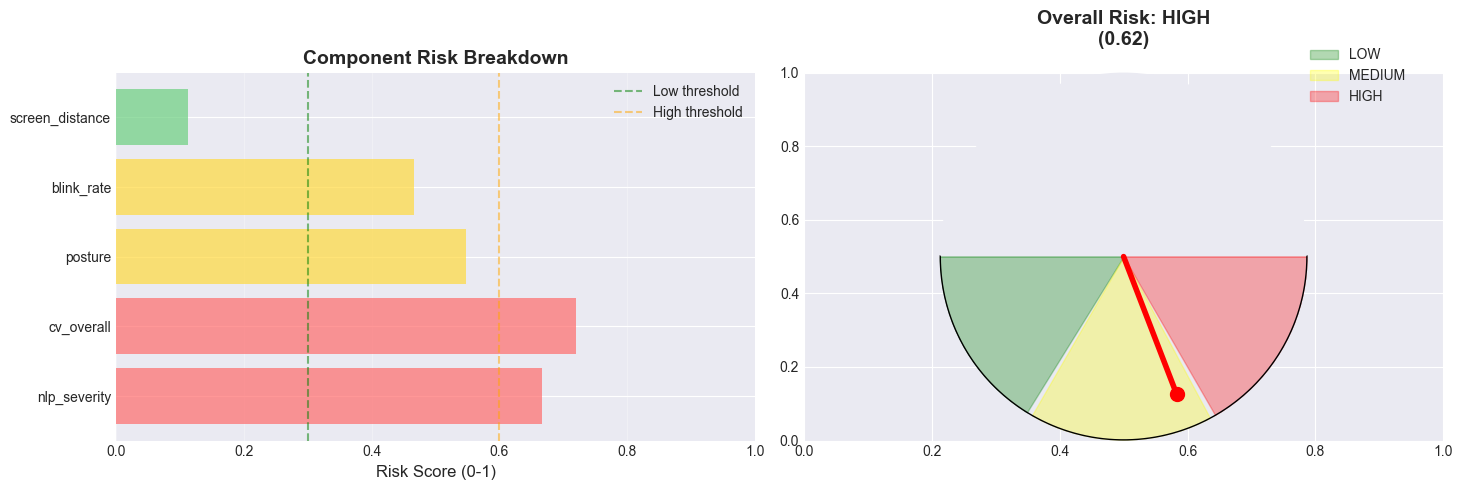

In [15]:
fig = visualize_risk_assessment(result_001)
plt.show()

In [16]:
nlp_features_002 = convert_nlp_output_to_features(nlp_output_samples[1])
cv_features_002 = convert_cv_data_to_features(cv_data_samples[1])

result_002 = pipeline.process(nlp_features_002, cv_features_002)

print("\n" + "="*70)
print("TEST CASE 2: MEDIUM RISK USER (User 002)")
print("="*70)

print(f"\nINPUT DATA:")
print(f"  User says: '{nlp_features_002.original_text}'")
print(f"  Severity: {nlp_features_002.severity_label} (confidence: {nlp_features_002.confidence:.2%})")
print_cv_metrics(result_002)

print(f"\nRISK ASSESSMENT:")
print(f"  Overall Risk: {result_002['risk_assessment']['combined_risk_score']:.2f}")
print(f"  Category: {result_002['risk_assessment']['risk_category']}")

print_recommendations(result_002)


TEST CASE 2: MEDIUM RISK USER (User 002)

INPUT DATA:
  User says: 'Mắt hơi khô và ngứa sau khi dùng máy tính một lúc'
  Severity: Nhẹ (confidence: 76.21%)

COMPUTER VISION METRICS

Blink Rate: 12/min (Normal: 15-20)
Posture Score: 68.5/100
Screen Distance: 55.0cm (Optimal: 50-70cm)
Work Duration: 45 minutes

RISK ASSESSMENT:
  Overall Risk: 0.31
  Category: MEDIUM

BEHAVIORAL RECOMMENDATIONS

1. [MEDIUM] Áp dụng quy tắc 20-20-20
   Cứ 20 phút, nhìn vật cách 20 feet (6 mét) trong 20 giây để thư giãn cơ mắt.
   Duration: 20 giây mỗi 20 phút
   Category: routine

2. [LOW] Tối ưu môi trường làm việc
   Giảm độ sáng màn hình, tránh ánh sáng chói phản chiếu, duy trì độ ẩm phòng 40-60%.
   Duration: Điều chỉnh khi có thể
   Category: environment


In [17]:
nlp_features_003 = convert_nlp_output_to_features(nlp_output_samples[2])
cv_features_003 = convert_cv_data_to_features(cv_data_samples[2])

result_003 = pipeline.process(nlp_features_003, cv_features_003)

print("\n" + "="*70)
print("TEST CASE 3: LOW RISK USER (User 003)")
print("="*70)

print(f"\nINPUT DATA:")
print(f"  User says: '{nlp_features_003.original_text}'")
print(f"  Severity: {nlp_features_003.severity_label}")
print_cv_metrics(result_003)

print(f"\nRISK ASSESSMENT:")
print(f"  Overall Risk: {result_003['risk_assessment']['combined_risk_score']:.2f}")
print(f"  Category: {result_003['risk_assessment']['risk_category']}")

print_recommendations(result_003)


TEST CASE 3: LOW RISK USER (User 003)

INPUT DATA:
  User says: 'Mắt ổn, không có vấn đề gì đặc biệt'
  Severity: Không có triệu chứng

COMPUTER VISION METRICS

Blink Rate: 18/min (Normal: 15-20)
Posture Score: 85.0/100
Screen Distance: 62.0cm (Optimal: 50-70cm)
Work Duration: 25 minutes

RISK ASSESSMENT:
  Overall Risk: 0.07
  Category: LOW

BEHAVIORAL RECOMMENDATIONS

1. [LOW] Tối ưu môi trường làm việc
   Giảm độ sáng màn hình, tránh ánh sáng chói phản chiếu, duy trì độ ẩm phòng 40-60%.
   Duration: Điều chỉnh khi có thể
   Category: environment


In [18]:
nlp_features_004 = convert_nlp_output_to_features(nlp_output_samples[3])
cv_features_004 = convert_cv_data_to_features(cv_data_samples[3])

result_004 = pipeline.process(nlp_features_004, cv_features_004)

print("\n" + "="*70)
print("TEST CASE 4: CRITICAL RISK USER (User 004)")
print("="*70)

print(f"\nINPUT DATA:")
print(f"  User says: '{nlp_features_004.original_text}'")
print(f"  Severity: {nlp_features_004.severity_label} (confidence: {nlp_features_004.confidence:.2%})")
print_cv_metrics(result_004)

print(f"\nRISK ASSESSMENT:")
print(f"  Overall Risk: {result_004['risk_assessment']['combined_risk_score']:.2f}")
print(f"  Category: {result_004['risk_assessment']['risk_category']}")
print(f"  Urgency: {result_004['risk_assessment']['urgency']}")

print(f"\nROOT CAUSE ANALYSIS:")
print(result_004['explanation']['root_cause'])

print_recommendations(result_004)

print(f"\n{result_004['disclaimer']}")


TEST CASE 4: CRITICAL RISK USER (User 004)

INPUT DATA:
  User says: 'Đau mắt quá trời, nhức đầu dữ dội, mắt đỏ và chảy nước mắt không ngừng. Không thể làm việc tiếp được nữa!!!'
  Severity: Nặng (confidence: 94.56%)

COMPUTER VISION METRICS

Blink Rate: 6/min (Normal: 15-20)
Posture Score: 32.8/100
Screen Distance: 28.0cm (Optimal: 50-70cm)
Work Duration: 180 minutes

RISK ASSESSMENT:
  Overall Risk: 0.84
  Category: HIGH
  Urgency: immediate

ROOT CAUSE ANALYSIS:
Triệu chứng 'Nặng' của bạn có thể do:

• Tần suất chớp mắt thấp (6 lần/phút so với mức bình thường 15-20 lần):
  Khi nhìn màn hình, não bộ tập trung cao độ khiến bạn quên chớp mắt, làm lớp
  nước mắt bốc hơi nhanh, gây khô và kích ứng mắt.

• Khoảng cách màn hình quá gần (28cm so với mức tối ưu 50-70cm):
  Mắt phải co cơ thể mi (ciliary muscle) liên tục để lấy nét ở khoảng cách gần,
  gây mỏi cơ và căng thẳng mắt (ciliary muscle fatigue).

• Tư thế ngồi kém (điểm: 33/100):
  Góc nhìn không phù hợp khiến mắt phải điều chỉnh 

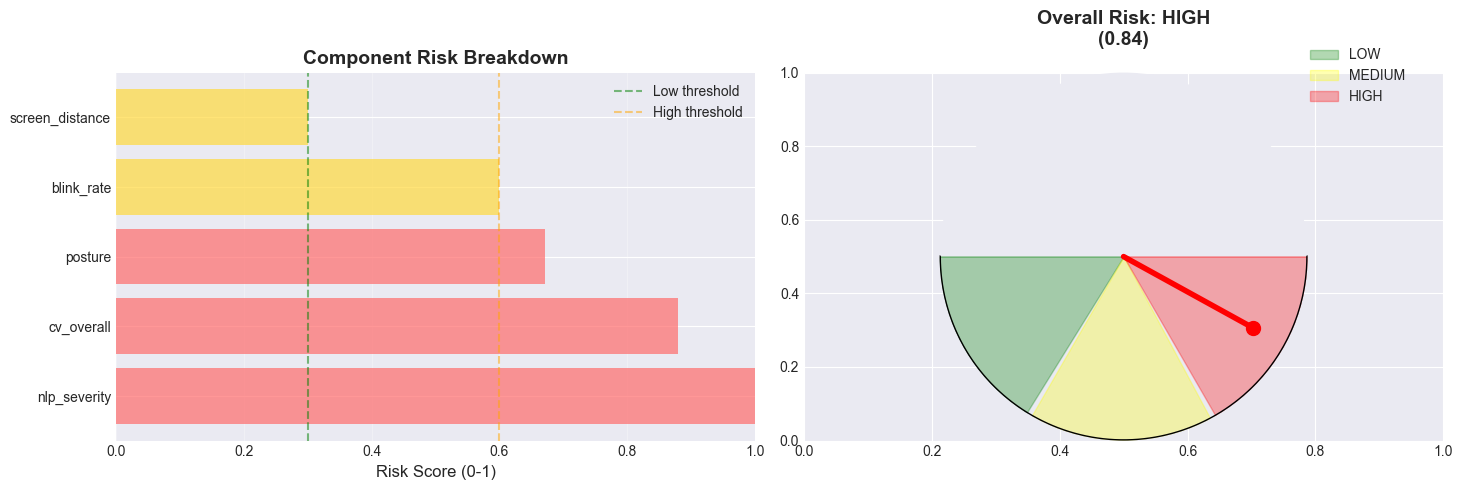

In [19]:
fig = visualize_risk_assessment(result_004)
plt.show()


COMPARISON ACROSS ALL USERS
 user_id  risk_score risk_category         nlp_severity  blink_rate  posture_score  num_recommendations
user_001    0.617158          HIGH                  Vừa           8           45.2                    6
user_002    0.305583        MEDIUM                  Nhẹ          12           68.5                    2
user_003    0.067500           LOW Không có triệu chứng          18           85.0                    1
user_004    0.839800          HIGH                 Nặng           6           32.8                    7
user_005    0.373217        MEDIUM                  Nhẹ          10           58.3                    4


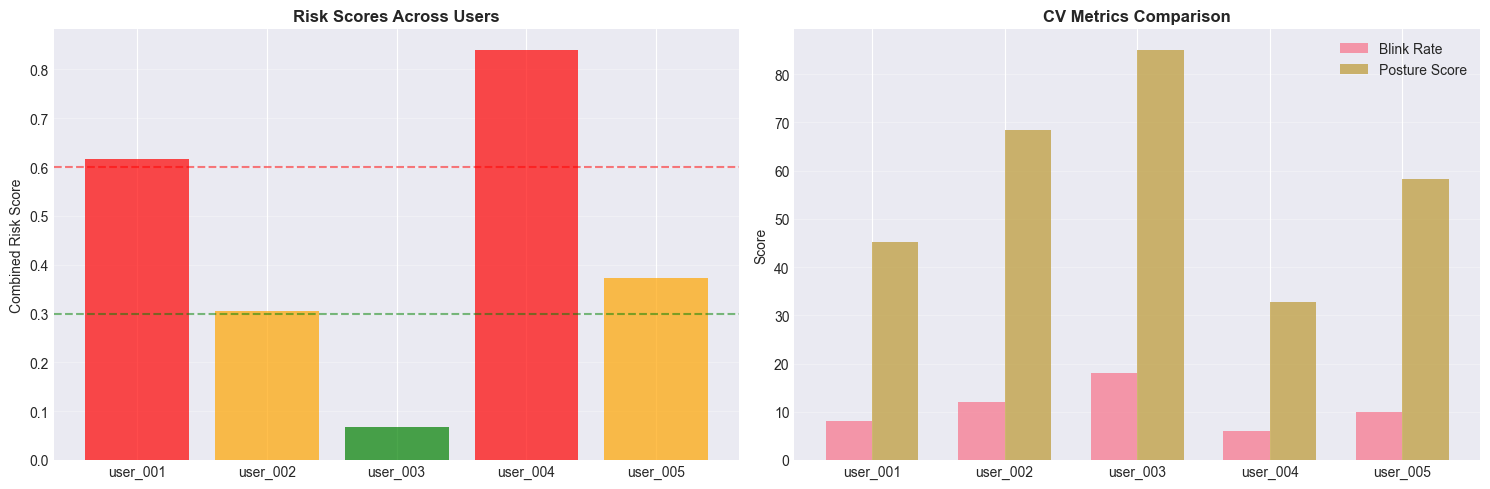

In [20]:
all_results = []
for i in range(len(cv_data_samples)):
    nlp_feat = convert_nlp_output_to_features(nlp_output_samples[i])
    cv_feat = convert_cv_data_to_features(cv_data_samples[i])
    result = pipeline.process(nlp_feat, cv_feat)
    all_results.append({
        'user_id': cv_data_samples[i]['user_id'],
        'risk_score': result['risk_assessment']['combined_risk_score'],
        'risk_category': result['risk_assessment']['risk_category'],
        'nlp_severity': nlp_feat.severity_label,
        'blink_rate': cv_feat.blink_rate,
        'posture_score': cv_feat.posture_score,
        'num_recommendations': len(result['recommendations'])
    })

comparison_df = pd.DataFrame(all_results)
print("\n" + "="*70)
print("COMPARISON ACROSS ALL USERS")
print("="*70)
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_map = {'LOW': 'green', 'MEDIUM': 'orange', 'HIGH': 'red'}
colors = [colors_map[cat] for cat in comparison_df['risk_category']]
axes[0].bar(comparison_df['user_id'], comparison_df['risk_score'], color=colors, alpha=0.7)
axes[0].set_ylabel('Combined Risk Score')
axes[0].set_title('Risk Scores Across Users', fontweight='bold')
axes[0].axhline(y=0.3, color='green', linestyle='--', alpha=0.5)
axes[0].axhline(y=0.6, color='red', linestyle='--', alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)

x = np.arange(len(comparison_df))
width = 0.35
axes[1].bar(x - width/2, comparison_df['blink_rate'], width, label='Blink Rate', alpha=0.7)
axes[1].bar(x + width/2, comparison_df['posture_score'], width, label='Posture Score', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['user_id'])
axes[1].set_ylabel('Score')
axes[1].set_title('CV Metrics Comparison', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
output_data = {
    'timestamp': datetime.now().isoformat(),
    'module': 'Module 2 - Multimodal Coaching',
    'total_users_processed': len(all_results),
    'results': [
        {
            'user_id': cv_data_samples[i]['user_id'],
            'session_id': cv_data_samples[i]['session_id'],
            'nlp_input': nlp_output_samples[i],
            'cv_input': cv_data_samples[i],
            'pipeline_output': pipeline.process(
                convert_nlp_output_to_features(nlp_output_samples[i]),
                convert_cv_data_to_features(cv_data_samples[i])
            )
        }
        for i in range(len(cv_data_samples))
    ]
}

with open('module2_results.json', 'w', encoding='utf-8') as f:
    json.dump(output_data, f, indent=2, ensure_ascii=False, default=str)

print(f"\nTotal users processed: {len(all_results)}")
print(f"High risk users: {sum(1 for r in all_results if r['risk_category'] == 'HIGH')}")
print(f"Medium risk users: {sum(1 for r in all_results if r['risk_category'] == 'MEDIUM')}")
print(f"Low risk users: {sum(1 for r in all_results if r['risk_category'] == 'LOW')}")


Total users processed: 5
High risk users: 2
Medium risk users: 2
Low risk users: 1
